In [1]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))
print(torch.version.cuda)

True
NVIDIA GeForce RTX 3070 Ti Laptop GPU
13.0


In [2]:

# Matplotlib
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
# Numpy
import numpy as np
# Pandas
import pandas as pd
# Torch
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchmetrics.classification import BinaryF1Score
# Imbalance handling
import importlib
# Helper functions (additional file)
from helper_functions import *

In [3]:
# Use GPU if available, else use CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [4]:
# Columns for dataset
filepath = 'train_creditcard.csv'
df = pd.read_csv(filepath)
print(df.columns)

# Load the dataset
V1, V2, V3, V4, V5, V6, V7, V8, V9, V10, V11, V12, V13, V14, V15, V16, V17, V18, V19, V20, V21, V22, V23, V24, V25, V26, V27, V28, amount, inputs, outputs = load_creditcard_dataset(filepath)

print("Input shape:", inputs.shape)
print("Output shape:", outputs.shape)
print("Number of samples with class 0:", len(outputs) - sum(outputs))
print("Number of samples with class 1:", sum(outputs))

print()


Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')
Input shape: (227845, 28)
Output shape: (227845,)
Number of samples with class 0: 227451
Number of samples with class 1: 394



In [5]:

class CreditCardDataset(Dataset):
    def __init__(self):
        self.dataframe = pd.read_csv(filepath)
        
    def __len__(self):
        return len(self.dataframe) 
    
    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        features = row[['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']].values.astype(np.float32)
        y = row['Class']
        inputs = torch.tensor(features, dtype=torch.float32)
        y = torch.tensor(y, dtype=torch.float32)
        return inputs, y        

In [6]:
feature_columns = [f'V{i}' for i in range(1, 29)] + ['Amount']
X_train = df[feature_columns].values.astype(np.float32)
y_train = df['Class'].values.astype(np.int64)

try:
    SMOTETomek = importlib.import_module('imblearn.combine').SMOTETomek
except ModuleNotFoundError as e:
    raise ModuleNotFoundError(
        "imblearn is required for SMOTE-Tomek. Install it with: pip install imbalanced-learn"
    ) from e

# Gentle augmentation: train set only, target fraud rate ~5%.
target_fraud_rate = 0.05
sampling_ratio = target_fraud_rate / (1.0 - target_fraud_rate)  # minority / majority

smote_tomek = SMOTETomek(sampling_strategy=sampling_ratio, random_state=42)
X_resampled, y_resampled = smote_tomek.fit_resample(X_train, y_train)

# If Tomek cleanup shifts ratio, trim excess fraud to keep it near 5%.
legit_idx = np.where(y_resampled == 0)[0]
fraud_idx = np.where(y_resampled == 1)[0]
target_fraud_count = int(round((target_fraud_rate / (1.0 - target_fraud_rate)) * len(legit_idx)))
if len(fraud_idx) > target_fraud_count:
    rng = np.random.default_rng(42)
    keep_fraud = rng.choice(fraud_idx, size=target_fraud_count, replace=False)
    keep_idx = np.concatenate([legit_idx, keep_fraud])
    rng.shuffle(keep_idx)
    X_resampled = X_resampled[keep_idx]
    y_resampled = y_resampled[keep_idx]

augmented_train_df = pd.DataFrame(X_resampled, columns=feature_columns)
augmented_train_df['Class'] = y_resampled.astype(np.float32)
augmented_filepath = 'train_creditcard_smotetomek_5pct.csv'
augmented_train_df.to_csv(augmented_filepath, index=False)

# Keep existing dataset class and training code unchanged.
filepath = augmented_filepath

print(f"Original train fraud rate: {100.0 * y_train.mean():.4f}%")
print(f"Augmented train fraud rate: {100.0 * augmented_train_df['Class'].mean():.4f}%")
print(f"Augmented train size: {len(augmented_train_df):,}")

cc_dataset  = CreditCardDataset()
batch_size = 128
cc_dataloader = DataLoader(cc_dataset, batch_size=batch_size, shuffle=True)

Original train fraud rate: 0.1729%
Augmented train fraud rate: 4.9970%
Augmented train size: 239,406


In [7]:
#Creation of a gated layer
class GatedLayer(nn.Module):
    def __init__(self, input_size, output_size):
        super(GatedLayer, self).__init__()
        self.linear = nn.Linear(input_size, output_size)  # Linear transformation
        self.gate = nn.Linear(input_size, output_size)    # Gate transformation
        self.sigmoid = nn.Sigmoid()                       # Sigmoid activation for gate

    def forward(self, x):
        linear_output = self.linear(x)                    # Compute linear output
        gate_output = self.sigmoid(self.gate(x))         # Compute gate output and apply sigmoid
        return linear_output * gate_output                # Element-wise multiplication of linear output and gate output

In [8]:
#Architecture of the model
class CreditCardFraudModel(nn.Module):
    def __init__(self):
        super().__init__()
        # Output layer with input size 8 and output size 1
        self.gated_layer = GatedLayer(29, 32)                 # Input layer with input size 29 (number of features) and output size 32
        self.hidden_layer1 = nn.Linear(32, 32)                # First hidden layer with input size 32 and output size 32
        self.output_layer = nn.Linear(32, 1)     # Output layer with input size 32 and output size 1

        # Activation functions
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
        
        self.dropout = nn.Dropout(p=0.1)  # Dropout layer with dropout probability of 0.3
        
        # Loss function and accuracy metric
        self.loss_fn = nn.BCELoss()
        self.accuracy_fn = BinaryF1Score()
        self.batchnorm1 = nn.BatchNorm1d(32)  # Batch normalization layer for hidden layer 1    
        

    def forward(self, x):
        x = self.gated_layer(x)                  # Pass through gated layer
        x = self.batchnorm1(x)                 # Apply batch normalization
        x = self.relu(x)                       # Apply ReLU activation
        x = self.hidden_layer1(x)               # Pass through first hidden layer
        x = self.relu(x)                       # Apply ReLU activation
        x = self.dropout(x)                    # Apply dropout
        x = self.output_layer(x)                # Pass through output layer
        return self.sigmoid(x)                 # Apply sigmoid activation to get output in range [0, 1]

In [9]:
model = CreditCardFraudModel()

total_params = sum(p.numel() for p in model.parameters())
print(f"Total trainable parameters: {total_params}")

Total trainable parameters: 3073


In [10]:

model = CreditCardFraudModel().to(device)

# Training hyperparameters
num_epochs = 100
# TODO: Set a reasonable learning rate
learning_rate = 0.0001

# Create optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

# Training history for plotting
loss_history = []
accuracy_history = []

# Training loop
for epoch in range(num_epochs):
    model.train()
    metric = BinaryF1Score().to(device)
    epoch_loss = 0.0
    num_batches = 0
    
    for batch in cc_dataloader:
        # Unpack batch
        inputs_batch, labels_batch = batch
        inputs_batch = inputs_batch.to(device)
        labels_batch = labels_batch.to(device).reshape(-1, 1)
        
        # TODO: Zero the gradients
        optimizer.zero_grad()
        # TODO: Forward pass - get predictions
        predictions = model(inputs_batch)
        # TODO: Compute loss
        loss = model.loss_fn(predictions, labels_batch.to(torch.float32))
        # TODO: Backward pass
        loss.backward()
        # TODO: Update weights
        optimizer.step()
        # Track metrics
        epoch_loss += loss.item()
        metric.update(predictions, labels_batch.int())
        num_batches += 1
    
    # Compute metrics at end of epoch
    avg_loss = epoch_loss / num_batches
    epoch_f1 = metric.compute().item()
    loss_history.append(avg_loss)
    accuracy_history.append(epoch_f1)
    
    # Print progress every epoch
   
    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}, F1-Score: {epoch_f1:.4f}')

print("Training complete!")

Epoch [1/100], Loss: 0.1753, F1-Score: 0.6551
Epoch [2/100], Loss: 0.0287, F1-Score: 0.9214
Epoch [3/100], Loss: 0.0215, F1-Score: 0.9385
Epoch [4/100], Loss: 0.0184, F1-Score: 0.9451
Epoch [5/100], Loss: 0.0161, F1-Score: 0.9509
Epoch [6/100], Loss: 0.0144, F1-Score: 0.9554
Epoch [7/100], Loss: 0.0129, F1-Score: 0.9597
Epoch [8/100], Loss: 0.0116, F1-Score: 0.9637
Epoch [9/100], Loss: 0.0107, F1-Score: 0.9669
Epoch [10/100], Loss: 0.0097, F1-Score: 0.9697
Epoch [11/100], Loss: 0.0090, F1-Score: 0.9711
Epoch [12/100], Loss: 0.0082, F1-Score: 0.9736
Epoch [13/100], Loss: 0.0078, F1-Score: 0.9749
Epoch [14/100], Loss: 0.0072, F1-Score: 0.9761
Epoch [15/100], Loss: 0.0068, F1-Score: 0.9781
Epoch [16/100], Loss: 0.0064, F1-Score: 0.9792
Epoch [17/100], Loss: 0.0061, F1-Score: 0.9807
Epoch [18/100], Loss: 0.0059, F1-Score: 0.9814
Epoch [19/100], Loss: 0.0053, F1-Score: 0.9840
Epoch [20/100], Loss: 0.0051, F1-Score: 0.9839
Epoch [21/100], Loss: 0.0050, F1-Score: 0.9845
Epoch [22/100], Loss: 

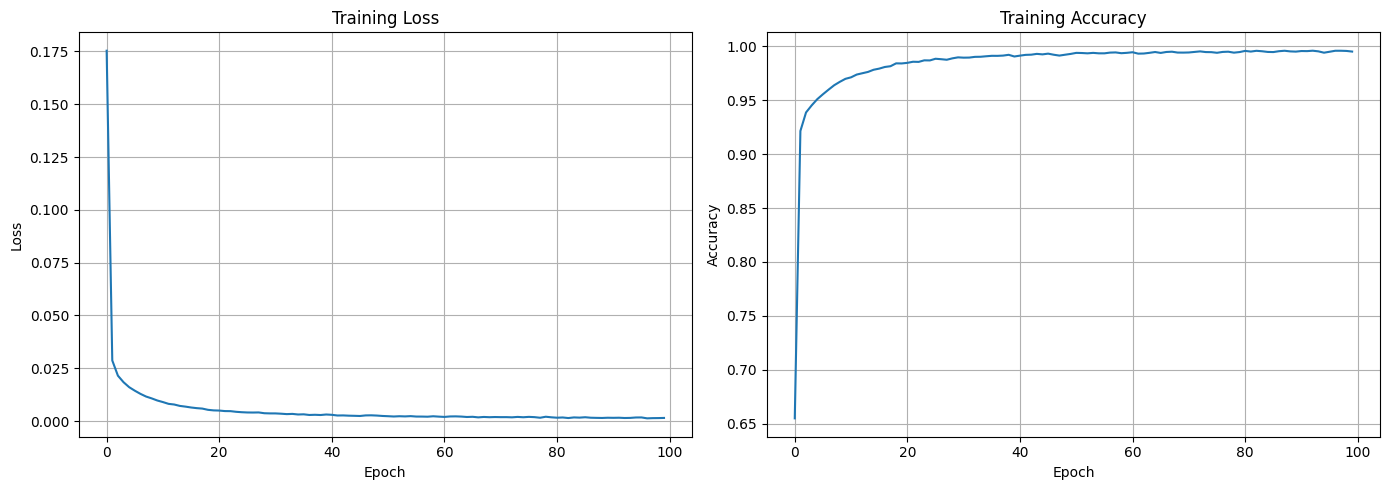

In [11]:
# Plot training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(loss_history)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training Loss')
ax1.grid(True)

ax2.plot(accuracy_history)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Training Accuracy')
ax2.grid(True)

plt.tight_layout()
plt.show()

In [12]:
test_file_path = 'test_creditcard.csv'
# Load test data with correct feature columns (including 'Amount')
test_df = pd.read_csv(test_file_path)
# Select the same 29 features as in training
feature_columns = [f'V{i}' for i in range(1, 29)] + ['Amount']
test_inputs = test_df[feature_columns].values.astype(np.float32)
test_labels = test_df['Class'].values.astype(np.float32)

# For compatibility with the rest of the notebook
inputs_test = test_inputs
outputs_test = test_labels


# Test the model on unseen data

In [13]:
# Convert test data to tensors
test_inputs = torch.tensor(test_inputs, dtype=torch.float32).to(device)
test_labels = torch.tensor(test_labels, dtype=torch.float32).to(device).reshape(-1, 1)

# Set model to evaluation mode
model.eval()

# Make predictions
with torch.no_grad():
    predictions = model(test_inputs)

# Calculate accuracy
test_accuracy = model.accuracy_fn(predictions, test_labels.int()).item()
print(f"Test Accuracy: {test_accuracy:.4f}")

# Also compute loss for comparison
test_loss = model.loss_fn(predictions, test_labels).item()
print(f"Test Loss: {test_loss:.4f}")

Test Accuracy: 0.8542
Test Loss: 0.0074
